# 2025 Race Telemetry Bad-Lap EDA

This notebook audits 2025 race-session telemetry quality in the local
Race Telemetry Workbench TimescaleDB import. It deliberately excludes
FP, qualifying, sprint qualifying, and sprint sessions.

The goal is not to fabricate a single "bad" score. The notebook builds
a transparent taxonomy of failure signals, keeps reason flags
non-mutually-exclusive, assigns a deterministic primary category for
reporting, and uses `skrub` plus scikit-learn-compatible tooling for
dataframe inspection and exploratory shape clustering.


## Runtime Contract

`skrub 0.9.0` uses `SKB_DATA_DIRECTORY` for its writable data directory.
Matplotlib must use a noninteractive backend in this sandbox. The
support module sets these paths before importing `skrub` or
Matplotlib, and all generated artifacts are written under
`artifacts/2025-telemetry-bad-lap-eda/`.


In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "notebooks").exists() and REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from notebooks import telemetry_bad_lap_support as eda

print(f"artifact dir: {eda.ARTIFACT_DIR}")
print(f"skrub data dir: {eda.SKRUB_DATA_DIR}")


artifact dir: /Users/fabio/Workspace/race-telemetry-workbench/artifacts/2025-telemetry-bad-lap-eda
skrub data dir: /Users/fabio/Workspace/race-telemetry-workbench/artifacts/2025-telemetry-bad-lap-eda/skrub-data


## Confirm Imported 2025 Race Coverage

Before classification, confirm the local database contains 2025 race
sessions. If this table is empty in another environment, import a
conservative validation slice first:

```bash
docker compose up -d timescaledb
.venv/bin/python scripts/download_session.py --year 2025 --event Monza
.venv/bin/python scripts/import_session.py --year 2025 --event Monza --mode upsert
```

For a full season import, keep concurrency conservative:

```bash
.venv/bin/python scripts/import_sessions.py --year 2025 --workers 2 --mode upsert
```


In [2]:
sessions = eda.load_session_inventory()
display(sessions)
print(f"2025 race sessions imported: {sessions['session_id'].nunique()}")


,event_round,session_id,year,event_name,circuit_name,country,session_type,session_start_utc,session_end_utc
0,1,2025-australian-grand-prix-r,2025,Australian Grand Prix,Melbourne,Australia,R,2025-03-16 04:00:00+00:00,None
1,2,2025-chinese-grand-prix-r,2025,Chinese Grand Prix,Shanghai,China,R,2025-03-23 07:00:00+00:00,None
2,3,2025-japanese-grand-prix-r,2025,Japanese Grand Prix,Suzuka,Japan,R,2025-04-06 05:00:00+00:00,None
3,4,2025-bahrain-grand-prix-r,2025,Bahrain Grand Prix,Sakhir,Bahrain,R,2025-04-13 15:00:00+00:00,None
4,5,2025-saudi-arabian-grand-prix-r,2025,Saudi Arabian Grand Prix,Jeddah,Saudi Arabia,R,2025-04-20 17:00:00+00:00,None
5,6,2025-miami-grand-prix-r,2025,Miami Grand Prix,Miami Gardens,United States,R,2025-05-04 20:00:00+00:00,None
6,7,2025-emilia-romagna-grand-prix-r,2025,Emilia Romagna Grand Prix,Imola,Italy,R,2025-05-18 13:00:00+00:00,None
7,8,2025-monaco-grand-prix-r,2025,Monaco Grand Prix,Monaco,Monaco,R,2025-05-25 13:00:00+00:00,None
8,9,2025-spanish-grand-prix-r,2025,Spanish Grand Prix,Barcelona,Spain,R,2025-06-01 13:00:00+00:00,None
9,10,2025-canadian-grand-prix-r,2025,Canadian Grand Prix,Montréal,Canada,R,2025-06-15 18:00:00+00:00,None


2025 race sessions imported: 24


## Skrub API Check

The installed package is `skrub` and this notebook uses the installed
`TableReport`, `Cleaner`, and `tabular_pipeline`-compatible API surface.
`tabular_learner` is not present in `skrub 0.9.0`, so the analysis
does not depend on that older/nonexistent symbol.


In [3]:
import inspect
import skrub

print("skrub version:", skrub.__version__)
for name in ["TableReport", "Cleaner", "tabular_pipeline", "GapEncoder", "StringEncoder"]:
    obj = getattr(skrub, name, None)
    print(name, "available:", obj is not None, "signature:", inspect.signature(obj) if obj else None)


skrub version: 0.9.0
TableReport available: True signature: (dataframe, n_rows=10, order_by=None, title=None, column_filters=None, verbose=None, plot_distributions='auto', compute_associations='auto', open_tab='table', max_plot_columns=None, max_association_columns=None)
Cleaner available: True signature: (drop_null_fraction=1.0, drop_if_constant=False, drop_if_unique=False, datetime_format=None, null_strings=None, parse_numbers=False, cast_to_float32=False, cast_to_str=False, n_jobs=1, numeric_dtype=None)
tabular_pipeline available: True signature: (estimator, *, n_jobs=None)
GapEncoder available: True signature: (n_components=10, batch_size=1024, gamma_shape_prior=1.1, gamma_scale_prior=1.0, rho=0.95, rescale_rho=False, hashing=False, hashing_n_features=4096, init='k-means++', max_iter=5, ngram_range=(2, 4), analyzer='char', add_words=False, random_state=None, rescale_W=True, max_iter_e_step=1, max_no_improvement=5, verbose=0)
StringEncoder available: True signature: (n_components=30

## Load, Classify, Cluster, and Write Artifacts

`run_analysis()` performs bounded all-race queries:

- one row per imported 2025 race lap,
- raw car telemetry sample counts, gaps, null rates, and channel bounds,
- raw position sample counts, path length, and segment discontinuity metrics,
- track-status and race-control context,
- 20 equal-lap-time speed bins used for shape residuals and clustering.

It then writes CSV tables, SVG figures, a `skrub.TableReport`, and the
markdown summary.


In [4]:
result = eda.run_analysis(write_outputs=True)

classified = result["classified"]
thresholds_df = result["thresholds_df"]
category_summary = result["category_summary"]
primary_summary = result["primary_summary"]
lens_summary = result["lens_summary"]
safety_summary = result["safety_summary"]
recommendation_summary = result["recommendation_summary"]
intersections = result["intersections"]
waterfall = result["waterfall"]
race_summary = result["race_summary"]
primary_by_race = result["primary_by_race"]
race_drilldowns = result["race_drilldowns"]
primary_audit = result["primary_audit"]
driver_race_matrix = result["driver_race_matrix"]
threshold_summary = result["threshold_summary"]
threshold_by_race = result["threshold_by_race"]
threshold_by_driver = result["threshold_by_driver"]
borderline_laps = result["borderline_laps"]
speed_profile_baselines = result["speed_profile_baselines"]
shape_profile_examples = result["shape_profile_examples"]
shape_cluster_exemplars = result["shape_cluster_exemplars"]
shape_cluster_stability = result["shape_cluster_stability"]
driver_summary = result["driver_summary"]
examples = result["examples"]
cluster_profile = result["cluster_profile"]

print(f"skrub version used: {result['skrub_version']}")
print(f"laps inspected: {len(classified):,}")
print(f"any-category bad laps: {classified['bad_lap_any_category'].sum():,}")
print(f"summary path: {result['summary_path']}")
print(f"skrub report path: {result['report_path']}")
print(f"metadata path: {result['metadata_path']}")


skrub version used: 0.9.0
laps inspected: 26,689
any-category bad laps: 5,497
summary path: /Users/fabio/Workspace/race-telemetry-workbench/docs/data-quality/2025-telemetry-bad-lap-eda-summary.md
skrub report path: /Users/fabio/Workspace/race-telemetry-workbench/artifacts/2025-telemetry-bad-lap-eda/skrub_lap_quality_table_report.html
metadata path: /Users/fabio/Workspace/race-telemetry-workbench/artifacts/2025-telemetry-bad-lap-eda/metadata.json


## Thresholds And Quality Lenses

Thresholds are explicit because each flag should map to a known
failure mode. The derived quality lenses separate data-integrity
failures from race context and exploratory speed-shape outliers.


In [5]:
display(thresholds_df)
display(lens_summary)
display(safety_summary)
display(recommendation_summary)


,threshold,value,rationale
0,min_car_samples,50.00,Reject laps with too little raw car-channel su...
1,min_position_samples,100.00,Reject laps with too little position support f...
2,min_lap_coverage_ratio,0.80,Flag laps where raw car telemetry covers too l...
3,path_length_tolerance_pct,0.05,Flag position paths that are materially shorte...
4,telemetry_p95_gap_ms,500.00,Flag sustained raw car telemetry cadence gaps.
5,telemetry_max_gap_ms,2000.00,Flag single large raw car telemetry gaps.
6,speed_min_kmh,0.00,Catch impossible negative speed values.
7,speed_max_kmh,380.00,Catch physically/source-improbable speed values.
8,rpm_min,0.00,Catch impossible negative RPM values.
9,rpm_max,16000.00,Catch source-improbable RPM values.


,lens,laps,pct_of_all_laps
0,data_integrity,3988,14.942486
3,analytical_shape,3224,12.079883
2,race_context,3199,11.986212
1,replay_blocking_integrity,477,1.787253
4,manual_review,58,0.217318


,derived_flag,laps,pct_of_all_laps
0,safe_for_replay,26212,98.212747
1,safe_for_lap_comparison,21192,79.403500
2,safe_for_geometry_reference,21192,79.403500
3,needs_manual_review,58,0.217318


,product_recommendation,laps,pct_of_all_laps
1,keep,21192,79.403500
2,keep_with_context_label,4966,18.606917
0,exclude,477,1.787253
3,manual_review,54,0.202331


## Taxonomy Counts

Reason columns are intentionally not mutually exclusive. For example,
a pit lap can also be FastF1-inaccurate and have an incomplete
telemetry window. The speed-shape outlier category is reported as
`atypical_speed_profile`; the compatibility source column remains
`shape_mismatch_against_comparable_laps`.


In [6]:
display(category_summary)
display(primary_summary)


,category,source_column,laps,pct_of_all_laps
8,import_or_source_data_anomaly,import_or_source_data_anomaly,3929,14.721421
4,atypical_speed_profile,shape_mismatch_against_comparable_laps,3224,12.079883
6,pit_lane_or_safety_car_influenced,pit_lane_or_safety_car_influenced,3199,11.986212
7,timing_session_boundary_artifact,timing_session_boundary_artifact,369,1.382592
1,incomplete_lap_window,incomplete_lap_window,352,1.318895
5,position_trace_discontinuity,position_trace_discontinuity,142,0.532054
9,unknown_needs_inspection,unknown_needs_inspection,54,0.202331
3,implausible_channel_values,implausible_channel_values,4,0.014987
2,distance_reset_or_non_monotonic_distance,distance_reset_or_non_monotonic_distance,0,0.000000
0,missing_or_sparse_telemetry,missing_or_sparse_telemetry,0,0.000000


,primary_category,laps,pct_of_all_laps
1,clean,21192,79.403500
4,pit_lane_or_safety_car_influenced,3087,11.566563
0,atypical_speed_profile,1559,5.841358
3,import_or_source_data_anomaly,374,1.401326
6,timing_session_boundary_artifact,369,1.382592
5,position_trace_discontinuity,107,0.400914
2,implausible_channel_values,1,0.003747


## Category Overlap And Waterfall

`reason_count` and `reason_set` are persisted on the classified-lap
table. The intersection table shows the most common overlapping
reason sets, while the waterfall assigns laps once in a deterministic
product-review order.


In [7]:
display(intersections.head(20))
display(waterfall)


,reason_set,reason_count,laps,races,drivers,pct_of_bad_laps,pct_of_all_laps
2,atypical_speed_profile + pit_lane_or_safety_ca...,3,1510,24,21,27.469529,5.657762
0,atypical_speed_profile + import_or_source_data...,2,1505,23,21,27.378570,5.639027
16,pit_lane_or_safety_car_influenced,1,1367,14,21,24.868110,5.121960
9,import_or_source_data_anomaly,1,374,24,21,6.803711,1.401326
15,incomplete_lap_window + timing_session_boundar...,3,238,5,21,4.329634,0.891753
17,pit_lane_or_safety_car_influenced + import_or_...,2,122,11,20,2.219392,0.457117
1,atypical_speed_profile + pit_lane_or_safety_ca...,2,88,1,18,1.600873,0.329724
12,incomplete_lap_window + pit_lane_or_safety_car...,4,80,7,20,1.455339,0.299749
7,atypical_speed_profile + unknown_needs_inspection,2,54,11,19,0.982354,0.202331
18,position_trace_discontinuity,1,43,3,20,0.782245,0.161115


,step,laps,pct_of_all_laps,remaining_laps_after_step
0,total_laps,26689,100.000000,26689
1,source_or_timing_excluded,3943,14.773877,22746
2,missing_or_incomplete_telemetry,0,0.000000,22746
3,implausible_channel_values,0,0.000000,22746
4,position_trace_discontinuity,45,0.168609,22701
5,race_context_influenced,1455,5.451684,21246
6,atypical_speed_profile,54,0.202331,21192
7,other_or_manual_review,0,0.000000,21192
8,clean_after_waterfall,21192,79.403500,0


## Race and Driver Concentration

These tables separate "how much bad data exists" from "where it is
concentrated." The category columns are counts; `bad_pct` is the
percentage of laps with at least one category flag. The primary-by-race
table powers the stacked race-decomposition figure.


In [8]:
display(race_summary.head(12))
display(primary_by_race[primary_by_race['primary_category'] != 'clean'].head(80))
display(driver_summary.head(15))


,event_round,event_name,total_laps,bad_laps,source_anomaly,pit_sc_context,sparse,incomplete,position,shape,timing,bad_pct
11,12,British Grand Prix,825,601,336,344,0,91,10,145,91,72.848485
12,13,Belgian Grand Prix,879,396,145,332,0,60,0,168,60,45.051195
0,1,Australian Grand Prix,927,410,364,235,0,69,7,295,69,44.228695
14,15,Dutch Grand Prix,1364,432,330,213,0,2,3,316,2,31.671554
20,21,São Paulo Grand Prix,1251,359,203,233,0,2,4,200,2,28.697042
22,23,Qatar Grand Prix,1067,272,163,194,0,3,3,142,3,25.492034
21,22,Las Vegas Grand Prix,886,219,126,124,0,2,1,115,19,24.717833
16,17,Azerbaijan Grand Prix,968,233,114,152,0,58,3,63,58,24.070248
6,7,Emilia Romagna Grand Prix,1207,272,254,93,0,2,3,242,2,22.535211
4,5,Saudi Arabian Grand Prix,898,179,100,117,0,37,1,52,37,19.933185


,event_round,event_name,primary_category,laps,race_laps,pct_of_race_laps
0,1,Australian Grand Prix,atypical_speed_profile,150,927,16.181230
2,1,Australian Grand Prix,import_or_source_data_anomaly,11,927,1.186624
3,1,Australian Grand Prix,pit_lane_or_safety_car_influenced,180,927,19.417476
4,1,Australian Grand Prix,timing_session_boundary_artifact,69,927,7.443366
5,2,Chinese Grand Prix,atypical_speed_profile,18,1065,1.690141
...,...,...,...,...,...,...
92,17,Azerbaijan Grand Prix,timing_session_boundary_artifact,58,968,5.991736
93,18,Singapore Grand Prix,atypical_speed_profile,20,1229,1.627339
95,18,Singapore Grand Prix,import_or_source_data_anomaly,18,1229,1.464605
96,18,Singapore Grand Prix,pit_lane_or_safety_car_influenced,46,1229,3.742880


,driver_code,total_laps,bad_laps,source_anomaly,pit_sc_context,sparse,incomplete,position,shape,timing,bad_pct
16,RUS,1442,317,227,179,0,18,18,186,19,21.983356
19,TSU,1386,294,208,181,0,16,6,171,17,21.212121
3,BEA,1373,291,212,164,0,18,8,168,19,21.194465
20,VER,1375,290,202,172,0,19,7,163,20,21.090909
13,NOR,1434,290,202,164,0,21,8,160,22,20.223152
7,GAS,1315,289,207,167,0,16,10,171,17,21.977186
0,ALB,1307,288,198,166,0,18,5,173,19,22.035195
18,STR,1317,285,198,171,0,19,5,170,19,21.640091
15,PIA,1394,282,204,167,0,18,6,164,19,20.229555
10,HUL,1287,280,203,157,0,18,5,165,19,21.756022


## Selected Race Drilldowns

British, Belgian, Australian, Dutch, and Sao Paulo are expanded because
they dominate the first-pass bad-rate table. Rows are grouped by race,
lap number, and deterministic primary category.


In [9]:
display(race_drilldowns[race_drilldowns['flagged_laps'] > 0].head(100))


,event_round,event_name,lap_number,primary_category,drivers,flagged_laps,median_lap_time_ms,median_speed_shape_rms_kmh,median_car_max_gap_ms,pit_sc_context_laps,source_anomaly_laps
0,1,Australian Grand Prix,1,atypical_speed_profile,15,15,132883.0,86.188087,1080.0,0,15
1,1,Australian Grand Prix,1,pit_lane_or_safety_car_influenced,2,2,149104.0,105.450275,1080.0,2,2
2,1,Australian Grand Prix,1,timing_session_boundary_artifact,3,3,NaN,NaN,1080.0,0,3
3,1,Australian Grand Prix,2,timing_session_boundary_artifact,17,17,NaN,NaN,1359.0,17,17
4,1,Australian Grand Prix,3,timing_session_boundary_artifact,17,17,NaN,NaN,1280.0,17,17
...,...,...,...,...,...,...,...,...,...,...,...
141,12,British Grand Prix,31,pit_lane_or_safety_car_influenced,15,15,104509.0,7.764547,1040.0,15,0
142,12,British Grand Prix,32,pit_lane_or_safety_car_influenced,15,15,104277.0,7.730610,1080.0,15,1
143,12,British Grand Prix,33,pit_lane_or_safety_car_influenced,15,15,104063.0,7.155066,1120.0,15,0
148,12,British Grand Prix,37,import_or_source_data_anomaly,1,1,103169.0,8.418238,920.0,0,1


## Driver/Race Matrix And Primary-Category Audit

The driver/race matrix separates all flags from integrity-only and
context-only rates. The audit table surfaces multi-reason laps where
the primary category may hide a useful secondary explanation.


In [10]:
display(driver_race_matrix.head(80))
display(primary_audit.head(80))


,event_round,event_name,driver_code,total_laps,bad_laps,integrity_laps,context_laps,shape_laps,replay_unsafe_laps,lap_comparison_unsafe_laps,bad_pct,integrity_pct,context_pct,shape_pct,replay_unsafe_pct,lap_comparison_unsafe_pct
220,12,British Grand Prix,ANT,23,19,19,7,7,6,19,82.608696,82.608696,30.434783,30.434783,26.086957,82.608696
224,12,British Grand Prix,HAD,18,14,14,3,8,4,14,77.777778,77.777778,16.666667,44.444444,22.222222,77.777778
219,12,British Grand Prix,ALO,52,40,20,24,9,5,40,76.923077,38.461538,46.153846,17.307692,9.615385,76.923077
225,12,British Grand Prix,HAM,52,39,21,22,9,5,39,75.000000,40.384615,42.307692,17.307692,9.615385,75.000000
235,12,British Grand Prix,TSU,51,38,20,22,8,5,38,74.509804,39.215686,43.137255,15.686275,9.803922,74.509804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,15,Dutch Grand Prix,HAD,72,22,16,12,16,0,22,30.555556,22.222222,16.666667,22.222222,0.000000,30.555556
291,15,Dutch Grand Prix,PIA,72,22,16,12,16,0,22,30.555556,22.222222,16.666667,22.222222,0.000000,30.555556
296,15,Dutch Grand Prix,VER,72,22,16,12,16,0,22,30.555556,22.222222,16.666667,22.222222,0.000000,30.555556
1,1,Australian Grand Prix,ALO,33,10,8,6,4,4,10,30.303030,24.242424,18.181818,12.121212,12.121212,30.303030


,event_round,event_name,driver_code,lap_number,primary_category,secondary_reason_set,reason_count,product_recommendation,safe_for_replay,safe_for_lap_comparison,coverage_deficit_pct,p95_gap_excess_ms,path_ratio_excess_pct,speed_shape_excess_kmh,audit_priority
16828,16,Italian Grand Prix,ALB,1,atypical_speed_profile,import_or_source_data_anomaly,2,keep_with_context_label,True,False,0.0,0.0,0.0,225.034494,229.034494
16829,16,Italian Grand Prix,ALB,2,atypical_speed_profile,unknown_needs_inspection,2,manual_review,True,False,0.0,0.0,0.0,225.034494,229.034494
16830,16,Italian Grand Prix,ALB,3,atypical_speed_profile,unknown_needs_inspection,2,manual_review,True,False,0.0,0.0,0.0,225.034494,229.034494
16831,16,Italian Grand Prix,ALB,4,atypical_speed_profile,unknown_needs_inspection,2,manual_review,True,False,0.0,0.0,0.0,225.034494,229.034494
16832,16,Italian Grand Prix,ALB,5,atypical_speed_profile,unknown_needs_inspection,2,manual_review,True,False,0.0,0.0,0.0,225.034494,229.034494
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10392,10,Canadian Grand Prix,HAD,13,pit_lane_or_safety_car_influenced,atypical_speed_profile + import_or_source_data...,3,keep_with_context_label,True,False,0.0,0.0,0.0,96.954564,102.954564
22223,20,Mexico City Grand Prix,TSU,37,pit_lane_or_safety_car_influenced,atypical_speed_profile + import_or_source_data...,3,keep_with_context_label,True,False,0.0,0.0,0.0,95.942378,101.942378
23192,21,São Paulo Grand Prix,PIA,39,pit_lane_or_safety_car_influenced,atypical_speed_profile + import_or_source_data...,3,keep_with_context_label,True,False,0.0,0.0,0.0,95.754206,101.754206
10626,10,Canadian Grand Prix,LAW,38,pit_lane_or_safety_car_influenced,atypical_speed_profile + import_or_source_data...,3,keep_with_context_label,True,False,0.0,0.0,0.0,95.342305,101.342305


## Threshold Sensitivity And Borderline Laps

Sensitivity scenarios loosen and tighten the main sample-count,
coverage, gap, path-ratio, and speed-shape thresholds. Borderline
laps are the laps whose bad flag, recommendation, safety, or primary
category changes under at least one scenario.


In [11]:
display(threshold_summary)
display(threshold_by_race.head(12))
display(threshold_by_driver.head(12))
display(borderline_laps.head(80))


,scenario,bad_laps,bad_pct,replay_unsafe_laps,lap_comparison_unsafe_laps,manual_review_laps,exclude_laps,context_label_laps,bad_laps_delta_vs_baseline,replay_unsafe_laps_delta_vs_baseline,lap_comparison_unsafe_laps_delta_vs_baseline,manual_review_laps_delta_vs_baseline,exclude_laps_delta_vs_baseline,context_label_laps_delta_vs_baseline,bad_flag_changed_laps,replay_safety_changed_laps,lap_comparison_safety_changed_laps,recommendation_changed_laps,primary_category_changed_laps
0,baseline,5497,20.596500,477,5497,58,477,4966,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
1,min_car_samples_loose,5497,20.596500,477,5497,58,477,4966,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
2,min_car_samples_strict,5497,20.596500,477,5497,58,477,4966,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
3,min_position_samples_loose,5497,20.596500,477,5497,58,477,4966,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
4,min_position_samples_strict,5497,20.596500,477,5497,58,477,4966,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
5,lap_coverage_loose,5497,20.596500,477,5497,58,477,4966,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
6,lap_coverage_strict,5497,20.596500,477,5497,58,477,4966,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
7,p95_gap_loose,5497,20.596500,477,5497,58,477,4966,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
8,p95_gap_strict,5504,20.622728,493,5504,58,493,4957,7,16,7,0,16,-9,7.0,16.0,7.0,16.0,16.0
9,max_gap_loose,5483,20.544044,460,5483,58,460,4969,-14,-17,-14,0,-17,3,14.0,17.0,14.0,17.0,17.0


,event_round,event_name,total_laps,threshold_sensitive_laps,bad_flag_sensitive_laps,recommendation_sensitive_laps,threshold_sensitive_pct
21,22,Las Vegas Grand Prix,886,19,14,17,2.144470
7,8,Monaco Grand Prix,1425,25,17,24,1.754386
5,6,Miami Grand Prix,1005,17,16,17,1.691542
16,17,Azerbaijan Grand Prix,968,15,14,15,1.549587
14,15,Dutch Grand Prix,1364,17,3,14,1.246334
18,19,United States Grand Prix,1067,11,0,7,1.030928
15,16,Italian Grand Prix,974,9,1,9,0.924025
0,1,Australian Grand Prix,927,7,6,6,0.755124
3,4,Bahrain Grand Prix,1128,7,0,1,0.620567
23,24,Abu Dhabi Grand Prix,1156,7,7,7,0.605536


,driver_code,total_laps,threshold_sensitive_laps,bad_flag_sensitive_laps,recommendation_sensitive_laps,threshold_sensitive_pct
2,ANT,1312,15,8,14,1.143293
13,NOR,1434,14,5,12,0.976290
15,PIA,1394,13,5,12,0.932568
12,LEC,1359,11,6,10,0.809419
9,HAM,1360,11,8,10,0.808824
19,TSU,1386,11,5,9,0.793651
10,HUL,1287,10,6,8,0.777001
16,RUS,1442,11,5,11,0.762829
7,GAS,1315,10,4,8,0.760456
8,HAD,1344,10,5,8,0.744048


,session_id,event_round,event_name,driver_code,lap_number,bad_flag_flip_count,replay_safety_flip_count,lap_comparison_safety_flip_count,recommendation_flip_count,primary_category_flip_count,baseline_bad_lap_any_category,baseline_safe_for_replay,baseline_safe_for_lap_comparison,baseline_product_recommendation,baseline_primary_category,any_sensitivity_flip_count
17596,2025-miami-grand-prix-r,6,Miami Grand Prix,ALB,53,1,1,1,1,1,False,True,True,keep,clean,5
17653,2025-miami-grand-prix-r,6,Miami Grand Prix,ALO,53,1,1,1,1,1,False,True,True,keep,clean,5
17709,2025-miami-grand-prix-r,6,Miami Grand Prix,ANT,53,1,1,1,1,1,False,True,True,keep,clean,5
17826,2025-miami-grand-prix-r,6,Miami Grand Prix,GAS,53,1,1,1,1,1,False,True,True,keep,clean,5
17883,2025-miami-grand-prix-r,6,Miami Grand Prix,HAD,53,1,1,1,1,1,False,True,True,keep,clean,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3213,2025-azerbaijan-grand-prix-r,17,Azerbaijan Grand Prix,ALB,5,1,0,1,1,1,True,True,False,manual_review,atypical_speed_profile,4
3264,2025-azerbaijan-grand-prix-r,17,Azerbaijan Grand Prix,ALO,5,1,0,1,1,1,True,True,False,manual_review,atypical_speed_profile,4
3366,2025-azerbaijan-grand-prix-r,17,Azerbaijan Grand Prix,BEA,5,1,0,1,1,1,True,True,False,manual_review,atypical_speed_profile,4
3417,2025-azerbaijan-grand-prix-r,17,Azerbaijan Grand Prix,BOR,5,1,0,1,1,1,False,True,True,keep,clean,4


## Speed-Shape Baselines And Cluster Stability

Shape examples are compared against clean green-flag same-race median
profiles with 10th-90th percentile bands. Cluster exemplars and
stability checks keep the exploratory clustering from being treated
as stronger evidence than it deserves.


In [12]:
display(speed_profile_baselines.head(40))
display(shape_profile_examples.head(20))
display(shape_cluster_exemplars.head(40))
display(shape_cluster_stability)


,session_id,event_round,event_name,speed_bin_number,reference_laps,speed_q10_kmh,speed_median_kmh,speed_q90_kmh
20,2025-australian-grand-prix-r,1,Australian Grand Prix,1,517,245.442857,258.062500,270.245833
21,2025-australian-grand-prix-r,1,Australian Grand Prix,2,517,141.347059,153.312500,165.727941
22,2025-australian-grand-prix-r,1,Australian Grand Prix,3,517,237.738562,250.058824,258.542222
23,2025-australian-grand-prix-r,1,Australian Grand Prix,4,517,172.037500,186.647059,203.739319
24,2025-australian-grand-prix-r,1,Australian Grand Prix,5,517,96.866667,102.125000,112.371429
25,2025-australian-grand-prix-r,1,Australian Grand Prix,6,517,147.631579,159.625000,175.858204
26,2025-australian-grand-prix-r,1,Australian Grand Prix,7,517,200.811765,224.500000,241.820833
27,2025-australian-grand-prix-r,1,Australian Grand Prix,8,517,186.465015,200.684211,211.942484
28,2025-australian-grand-prix-r,1,Australian Grand Prix,9,517,227.055556,249.722222,261.053333
29,2025-australian-grand-prix-r,1,Australian Grand Prix,10,517,282.911373,289.529412,294.294118


,session_id,event_round,event_name,driver_code,lap_number,primary_category,reason_set,lap_time_ms,speed_shape_rms_kmh,speed_shape_excess_kmh,speed_shape_robust_z,is_pit_in_lap,is_pit_out_lap,safety_car_periods,virtual_safety_car_periods,red_flag_periods
16829,2025-italian-grand-prix-r,16,Italian Grand Prix,ALB,2,atypical_speed_profile,atypical_speed_profile + unknown_needs_inspection,85762.0,256.237164,225.034494,78.416582,False,False,0,0,0
16830,2025-italian-grand-prix-r,16,Italian Grand Prix,ALB,3,atypical_speed_profile,atypical_speed_profile + unknown_needs_inspection,85238.0,256.237164,225.034494,78.416582,False,False,0,0,0
16831,2025-italian-grand-prix-r,16,Italian Grand Prix,ALB,4,atypical_speed_profile,atypical_speed_profile + unknown_needs_inspection,85427.0,256.237164,225.034494,78.416582,False,False,0,0,0
16832,2025-italian-grand-prix-r,16,Italian Grand Prix,ALB,5,atypical_speed_profile,atypical_speed_profile + unknown_needs_inspection,84598.0,256.237164,225.034494,78.416582,False,False,0,0,0
16833,2025-italian-grand-prix-r,16,Italian Grand Prix,ALB,6,atypical_speed_profile,atypical_speed_profile + unknown_needs_inspection,84743.0,256.237164,225.034494,78.416582,False,False,0,0,0
16834,2025-italian-grand-prix-r,16,Italian Grand Prix,ALB,7,atypical_speed_profile,atypical_speed_profile + unknown_needs_inspection,84736.0,256.237164,225.034494,78.416582,False,False,0,0,0
16835,2025-italian-grand-prix-r,16,Italian Grand Prix,ALB,8,atypical_speed_profile,atypical_speed_profile + unknown_needs_inspection,84553.0,256.237164,225.034494,78.416582,False,False,0,0,0
16836,2025-italian-grand-prix-r,16,Italian Grand Prix,ALB,9,atypical_speed_profile,atypical_speed_profile + unknown_needs_inspection,84647.0,256.237164,225.034494,78.416582,False,False,0,0,0
16837,2025-italian-grand-prix-r,16,Italian Grand Prix,ALB,10,atypical_speed_profile,atypical_speed_profile + unknown_needs_inspection,84453.0,256.237164,225.034494,78.416582,False,False,0,0,0
16838,2025-italian-grand-prix-r,16,Italian Grand Prix,ALB,11,atypical_speed_profile,atypical_speed_profile + unknown_needs_inspection,84514.0,173.520831,142.318161,52.474833,False,False,0,0,0


,cluster,exemplar_type,event_round,event_name,driver_code,lap_number,primary_category,common_primary_category,speed_shape_rms_kmh,speed_shape_excess_kmh,cluster_distance,reason_set
2,0,common_primary_category_example,20,Mexico City Grand Prix,COL,1,atypical_speed_profile,atypical_speed_profile,98.995220,67.700090,41.513479,atypical_speed_profile + import_or_source_data...
1,0,highest_shape_severity,20,Mexico City Grand Prix,COL,1,atypical_speed_profile,atypical_speed_profile,98.995220,67.700090,41.513479,atypical_speed_profile + import_or_source_data...
0,0,nearest_centroid,18,Singapore Grand Prix,RUS,1,atypical_speed_profile,atypical_speed_profile,46.892534,15.889140,11.791357,atypical_speed_profile + import_or_source_data...
5,1,common_primary_category_example,10,Canadian Grand Prix,STR,51,pit_lane_or_safety_car_influenced,pit_lane_or_safety_car_influenced,129.929037,97.542322,42.538696,atypical_speed_profile + pit_lane_or_safety_ca...
4,1,highest_shape_severity,16,Italian Grand Prix,ALB,1,atypical_speed_profile,pit_lane_or_safety_car_influenced,256.237164,225.034494,99.599641,atypical_speed_profile + import_or_source_data...
3,1,nearest_centroid,10,Canadian Grand Prix,ANT,68,pit_lane_or_safety_car_influenced,pit_lane_or_safety_car_influenced,108.092248,75.705534,11.997862,atypical_speed_profile + pit_lane_or_safety_ca...
8,2,common_primary_category_example,12,British Grand Prix,BEA,4,clean,clean,43.879321,0.000000,23.897874,clean
7,2,highest_shape_severity,1,Australian Grand Prix,LEC,44,atypical_speed_profile,clean,71.481832,38.242410,38.350681,atypical_speed_profile + unknown_needs_inspection
6,2,nearest_centroid,23,Qatar Grand Prix,NOR,5,clean,clean,3.349763,0.000000,2.764494,clean
11,3,common_primary_category_example,5,Saudi Arabian Grand Prix,HUL,1,atypical_speed_profile,atypical_speed_profile,113.135344,81.797881,39.419493,atypical_speed_profile + import_or_source_data...


,k,seed,sampled_laps,silhouette,ari_vs_seed_0
0,5,0,5000,0.719351,1.000000
1,5,1,5000,0.712697,1.000000
2,5,2,5000,0.722506,1.000000
3,6,0,5000,0.727724,1.000000
4,6,1,5000,0.717030,0.999905
5,6,2,5000,0.728601,0.999895
6,7,0,5000,0.715755,1.000000
7,7,1,5000,0.716757,0.982815
8,7,2,5000,0.686226,0.943106
9,8,0,5000,0.683948,1.000000


## Representative Examples

The examples table is selected by category-specific severity: speed
profile RMS for shape mismatch, path deviation or segment jump for
position discontinuity, low coverage for incomplete windows, and large
sample gaps for timing/session artifacts.


In [13]:
display(examples)


,category,event_round,event_name,driver_code,lap_number,primary_category,reason_count,reason_set,lap_time_ms,car_samples,position_samples,speed_shape_rms_kmh,position_path_ratio,position_max_segment_units,car_max_gap_ms,car_coverage_ratio
0,incomplete_lap_window,1,Australian Grand Prix,ALB,2,timing_session_boundary_artifact,4,incomplete_lap_window + pit_lane_or_safety_car...,NaN,616,634,NaN,0.999978,594.838634,1359.0,NaN
1,incomplete_lap_window,1,Australian Grand Prix,ALB,3,timing_session_boundary_artifact,4,incomplete_lap_window + pit_lane_or_safety_car...,NaN,601,631,NaN,1.002334,638.420708,1280.0,NaN
2,incomplete_lap_window,1,Australian Grand Prix,ALB,4,timing_session_boundary_artifact,4,incomplete_lap_window + pit_lane_or_safety_car...,NaN,568,588,NaN,1.004128,449.662095,961.0,NaN
3,incomplete_lap_window,1,Australian Grand Prix,ALO,2,timing_session_boundary_artifact,4,incomplete_lap_window + pit_lane_or_safety_car...,NaN,618,637,NaN,1.003492,616.623062,1359.0,NaN
4,incomplete_lap_window,1,Australian Grand Prix,ALO,3,timing_session_boundary_artifact,4,incomplete_lap_window + pit_lane_or_safety_car...,NaN,600,628,NaN,1.004200,568.919151,1280.0,NaN
5,implausible_channel_values,1,Australian Grand Prix,PIA,44,timing_session_boundary_artifact,6,incomplete_lap_window + implausible_channel_va...,NaN,719,739,NaN,1.127187,2859.845101,1201.0,NaN
6,implausible_channel_values,8,Monaco Grand Prix,BOR,1,implausible_channel_values,5,implausible_channel_values + atypical_speed_pr...,145564.0,534,546,87.683933,1.051193,573.247765,1041.0,1.001079
7,implausible_channel_values,21,São Paulo Grand Prix,BOR,1,timing_session_boundary_artifact,5,incomplete_lap_window + implausible_channel_va...,NaN,295,308,NaN,0.671537,362.604468,960.0,NaN
8,implausible_channel_values,23,Qatar Grand Prix,HUL,7,timing_session_boundary_artifact,5,incomplete_lap_window + implausible_channel_va...,NaN,563,564,NaN,0.183039,646.877114,1160.0,NaN
9,atypical_speed_profile,16,Italian Grand Prix,ALB,4,atypical_speed_profile,2,atypical_speed_profile + unknown_needs_inspection,85427.0,319,320,256.237164,1.000267,1099.027297,1280.0,0.994522


## Shape Clusters

The clustering is exploratory. It uses speed-profile bins and compact
telemetry/position quality features to surface shape families and
outlier regions. It is not used as the sole source of truth for source
defects.


In [14]:
display(cluster_profile)


,cluster,laps,bad_pct,median_shape_rms,median_lap_time_ms,median_car_coverage,pit_sc_pct,source_anomaly_pct,position_discontinuity_pct,pca_variance_1,pca_variance_2,silhouette
0,0,494,100.000000,64.283068,96003.0,0.998579,15.789474,99.797571,5.465587,0.331957,0.218749,0.701827
1,1,129,100.000000,107.084098,106030.0,0.997541,78.294574,93.023256,0.775194,0.331957,0.218749,0.701827
3,3,1224,100.000000,78.437963,122948.0,0.997696,20.343137,98.856209,0.163399,0.331957,0.218749,0.701827
4,4,563,100.000000,104.256820,111552.0,0.997596,99.467140,99.822380,2.664298,0.331957,0.218749,0.701827
6,6,35,100.000000,74.666586,97342.0,0.997148,0.000000,100.000000,100.000000,0.331957,0.218749,0.701827
5,5,661,99.848714,56.606774,95572.0,0.996914,83.509834,99.848714,0.453858,0.331957,0.218749,0.701827
2,2,23583,10.142900,6.339566,87420.0,0.996773,7.034728,3.600051,0.250180,0.331957,0.218749,0.701827


## Cross-Check With Standalone Apexline Work

Apexline's existing 2025 diagnostics are geometry-reference checks
against GPS circuit outlines. This notebook uses the imported database
surface for all-lap telemetry quality, while Apexline remains the
stronger reference for GPS-shape validation.


In [15]:
display(result["apexline_summary"].head(24))
display(result["apexline_examples"].head(20))


,event_name,event_round,apexline_total_laps,apexline_bad_laps,apexline_good_pct,apexline_shape_bad_laps,apexline_fastf1_inaccurate,apexline_pit_lap,apexline_missing_lap_time,apexline_path_length_outlier
0,Australian Grand Prix,1,927,359,61.272923,0,359,132,69,5
1,Chinese Grand Prix,2,1065,70,93.427230,0,70,52,0,0
2,Japanese Grand Prix,3,1059,62,94.145420,0,62,42,0,0
3,Bahrain Grand Prix,4,1128,176,84.397163,0,176,84,13,13
4,Saudi Arabian Grand Prix,5,898,89,90.089087,1,88,39,37,1
5,Miami Grand Prix,6,1005,144,85.671642,0,144,38,3,4
6,Emilia Romagna Grand Prix,7,1207,251,79.204640,0,251,75,2,2
7,Monaco Grand Prix,8,1425,154,89.192982,0,154,81,2,9
8,Spanish Grand Prix,9,1203,213,82.294264,0,213,109,1,1
9,Canadian Grand Prix,10,1349,192,85.767235,0,152,131,3,42


,event_name,event_round,driver_code,lap_number,reasons,shape_rmse_m,shape_p95_m,path_length_m,length_error_pct
0,Saudi Arabian Grand Prix,5,HUL,25,shape_rmse_over_threshold,25.301288,30.699969,6109.738546,-0.013971
1,British Grand Prix,12,ALO,24,shape_rmse_over_threshold,25.284504,43.454590,5892.635987,0.002520
2,Belgian Grand Prix,13,STR,6,"shape_rmse_over_threshold,shape_p95_over_thres...",34.789762,55.709396,7109.307272,0.018765
3,Belgian Grand Prix,13,STR,19,"shape_rmse_over_threshold,shape_p95_over_thres...",31.096456,60.040760,7001.106375,0.003260
4,Belgian Grand Prix,13,TSU,5,shape_rmse_over_threshold,27.923491,44.889642,6968.289007,-0.001443
5,Belgian Grand Prix,13,STR,15,shape_rmse_over_threshold,27.359697,46.858095,6970.912049,-0.001067
6,Belgian Grand Prix,13,HAD,10,shape_rmse_over_threshold,27.311826,42.345282,6946.897799,-0.004508
7,Belgian Grand Prix,13,PIA,5,shape_rmse_over_threshold,27.287288,42.246510,6945.595857,-0.004694
8,Belgian Grand Prix,13,ALO,44,shape_rmse_over_threshold,27.272838,42.338968,6947.341635,-0.004444
9,Belgian Grand Prix,13,RUS,16,shape_rmse_over_threshold,27.171755,42.231360,6947.635088,-0.004402


## Visual Artifacts

The notebook writes professional static artifacts so the analysis can
be reviewed without re-running the notebook.


artifacts/2025-telemetry-bad-lap-eda/figures/category_counts.svg


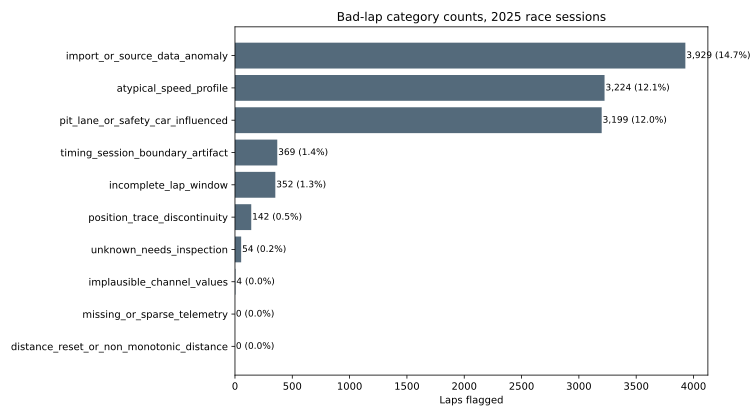

artifacts/2025-telemetry-bad-lap-eda/figures/race_bad_lap_rates.svg


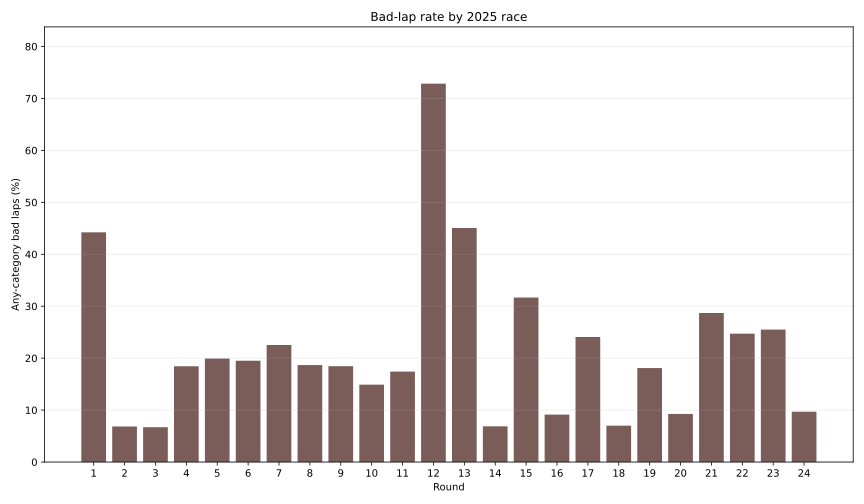

artifacts/2025-telemetry-bad-lap-eda/figures/category_intersections.svg


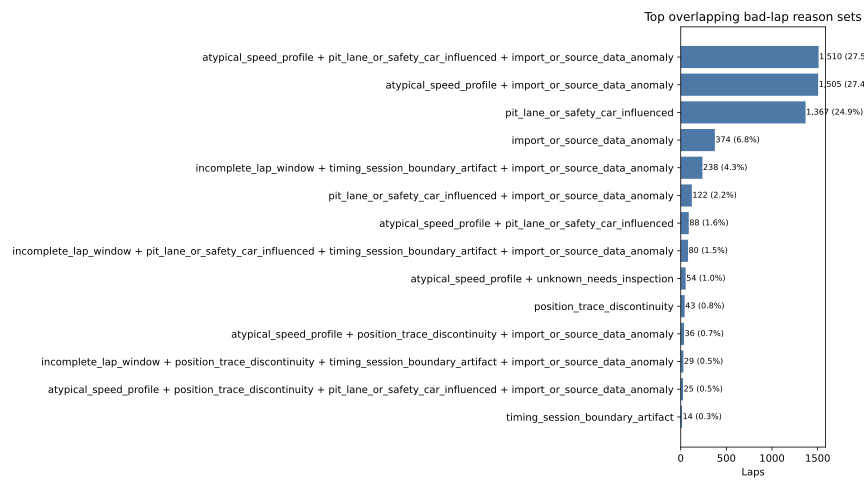

artifacts/2025-telemetry-bad-lap-eda/figures/decision_waterfall.svg


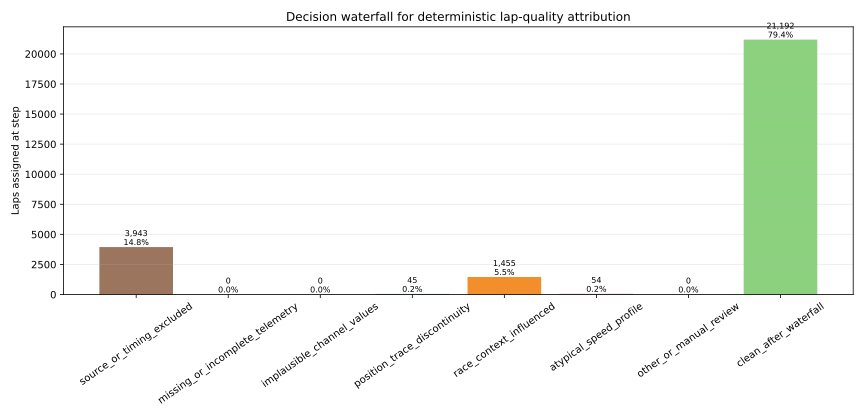

artifacts/2025-telemetry-bad-lap-eda/figures/race_primary_category_decomposition.svg


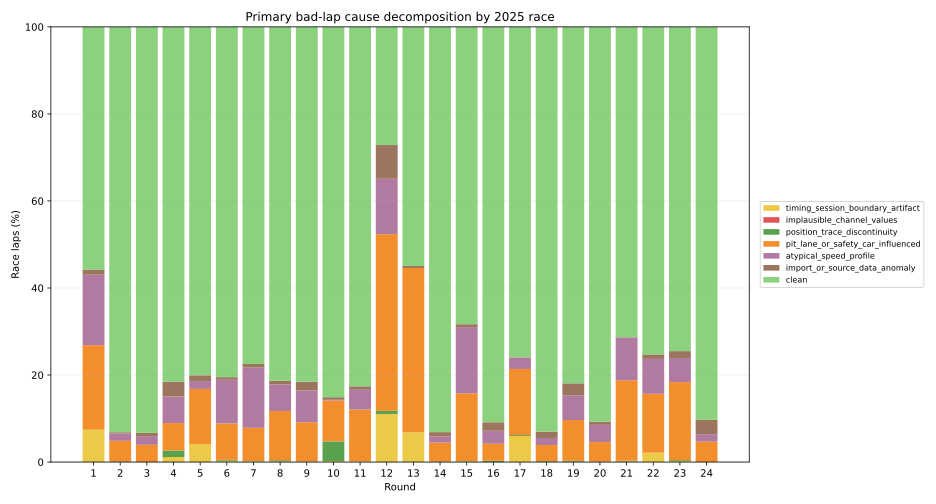

artifacts/2025-telemetry-bad-lap-eda/figures/selected_race_drilldowns.svg


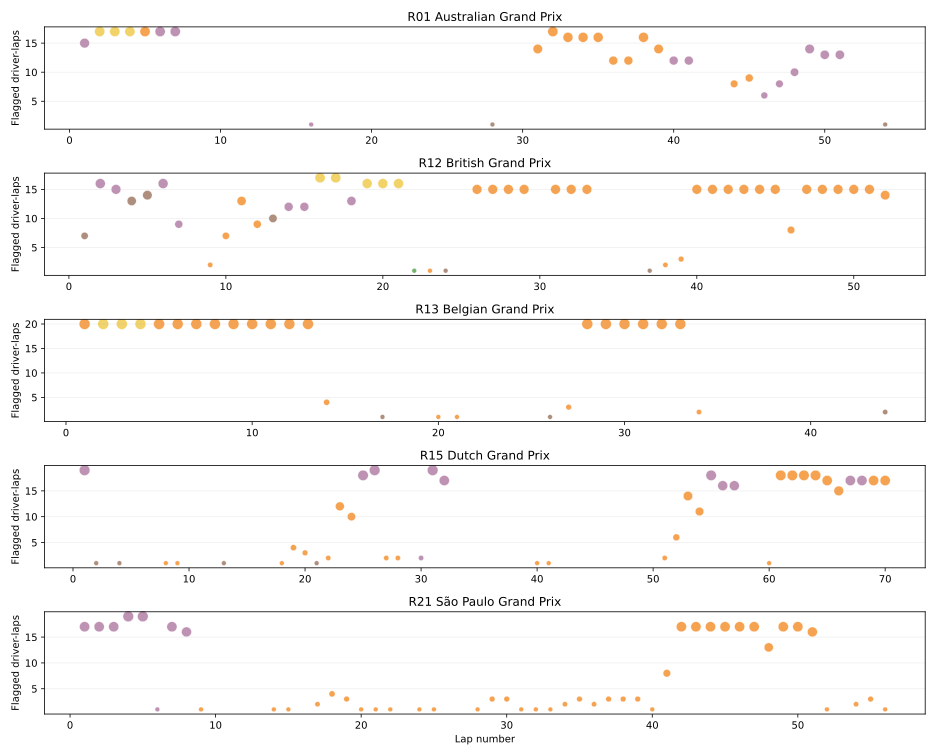

artifacts/2025-telemetry-bad-lap-eda/figures/lap_number_primary_category_heatmap.svg


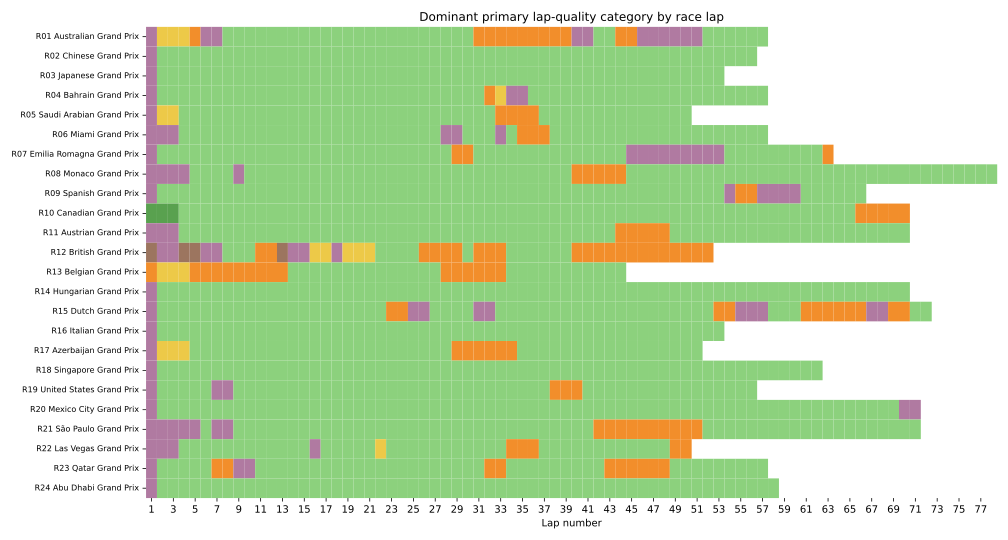

artifacts/2025-telemetry-bad-lap-eda/figures/driver_race_quality_matrix.svg


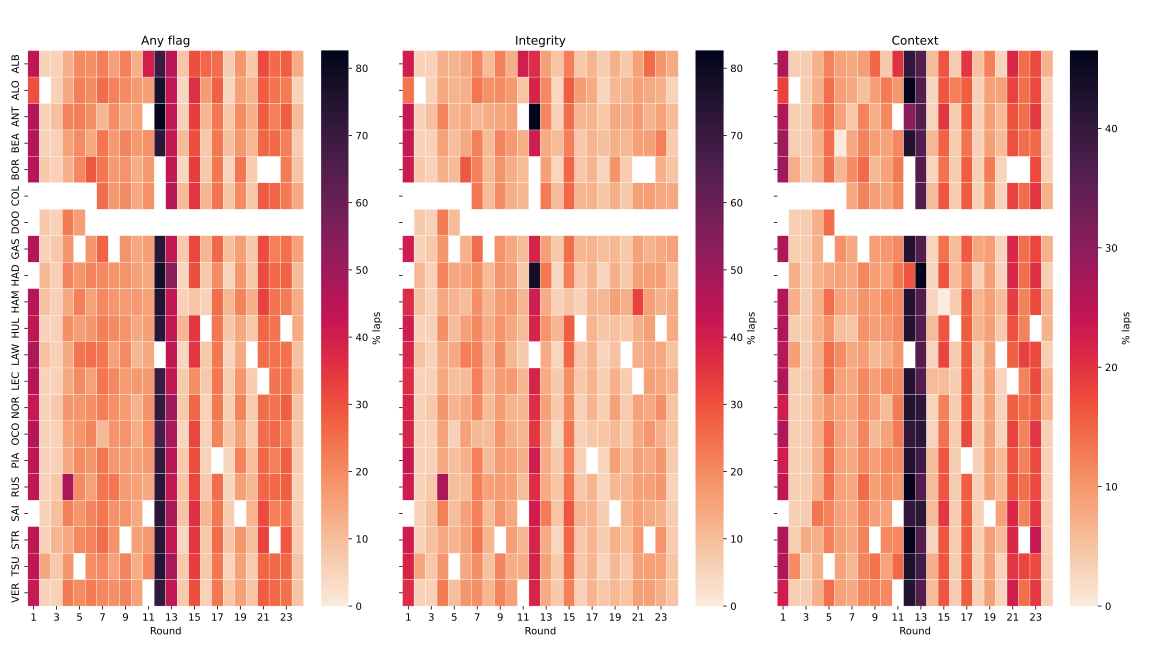

artifacts/2025-telemetry-bad-lap-eda/figures/recommendation_summary.svg


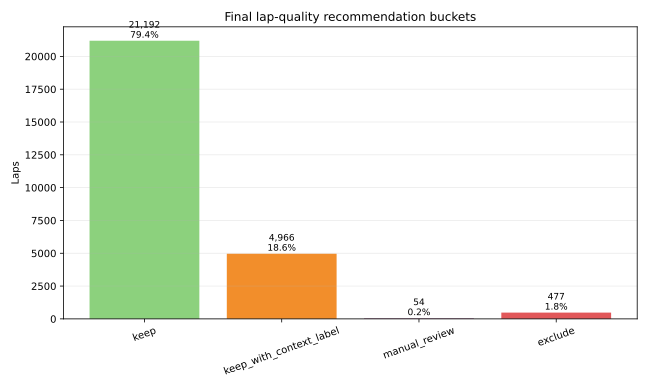

artifacts/2025-telemetry-bad-lap-eda/figures/threshold_sensitivity.svg


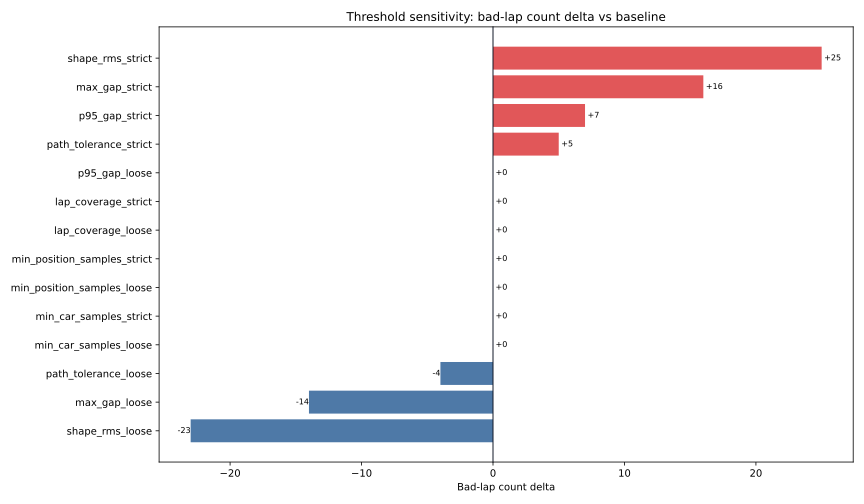

artifacts/2025-telemetry-bad-lap-eda/figures/borderline_laps_by_race.svg


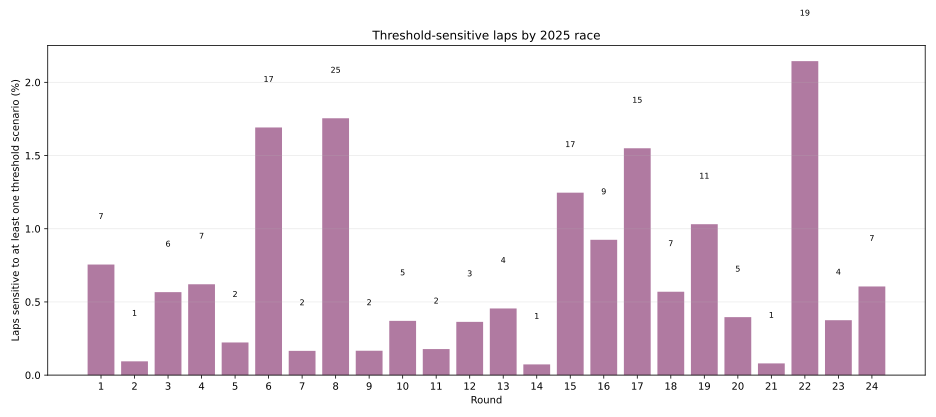

artifacts/2025-telemetry-bad-lap-eda/figures/missingness_by_race.svg


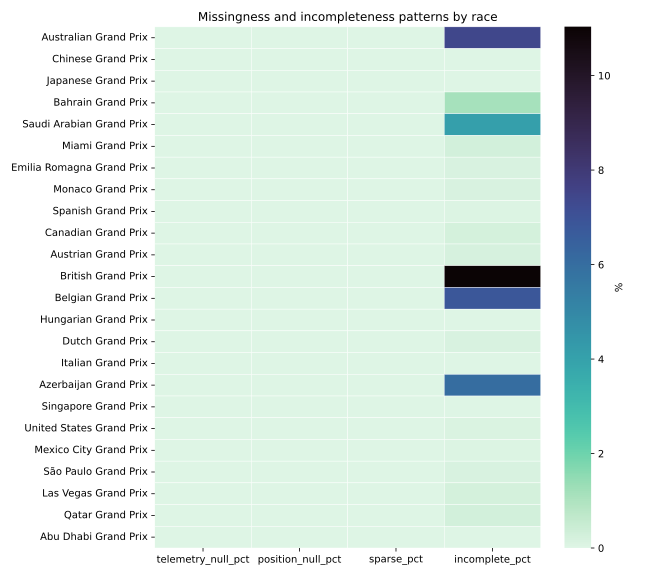

artifacts/2025-telemetry-bad-lap-eda/figures/shape_clusters.svg


artifacts/2025-telemetry-bad-lap-eda/figures/representative_speed_shapes.svg


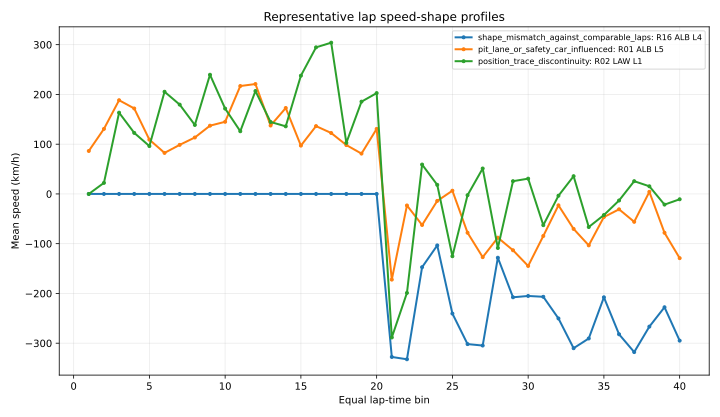

artifacts/2025-telemetry-bad-lap-eda/figures/shape_profile_quantile_bands.svg


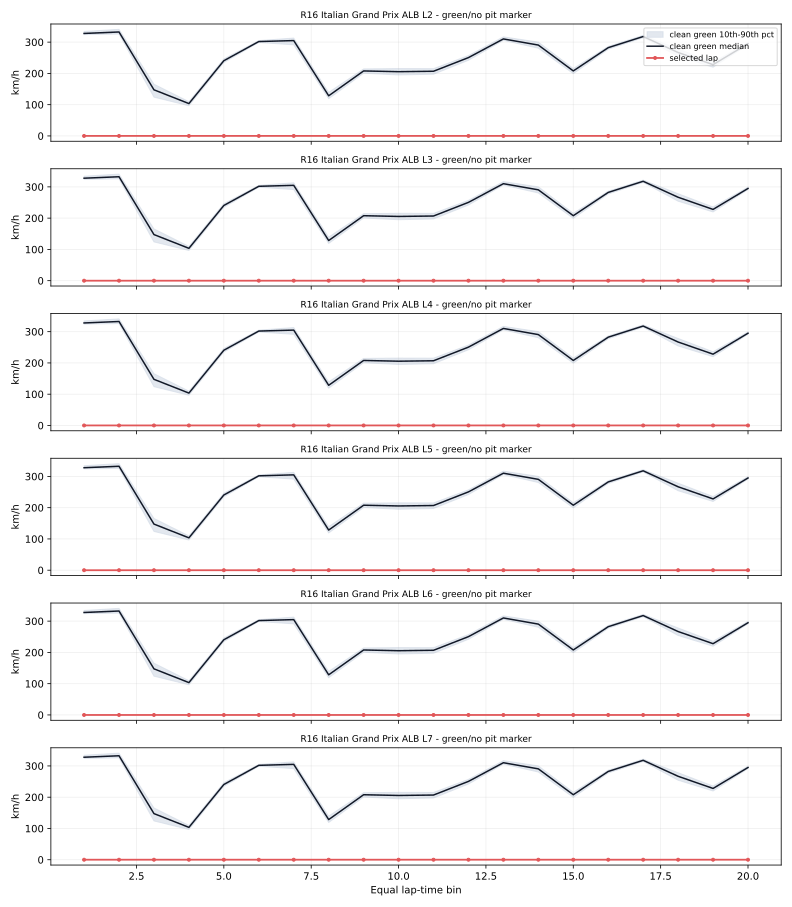

artifacts/2025-telemetry-bad-lap-eda/figures/shape_cluster_stability.svg


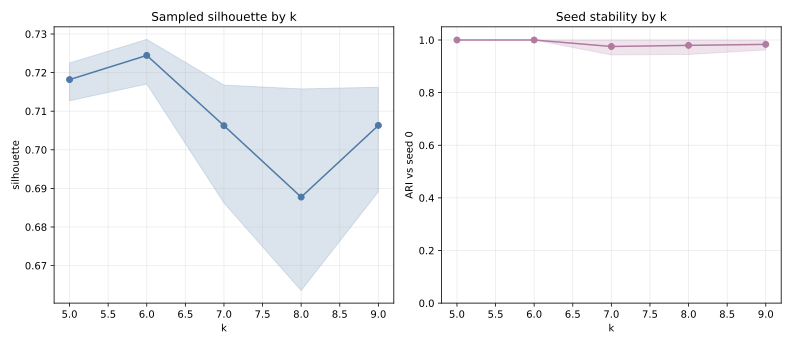

In [16]:
from IPython.display import SVG, display

for path in result["figure_paths"]:
    print(path.relative_to(REPO_ROOT))
    display(SVG(filename=str(path)))


## Outputs

The primary written outputs are:

- `docs/data-quality/2025-telemetry-bad-lap-eda-summary.md`
- `artifacts/2025-telemetry-bad-lap-eda/skrub_lap_quality_table_report.html`
- `artifacts/2025-telemetry-bad-lap-eda/tables/*.csv`
- `artifacts/2025-telemetry-bad-lap-eda/tables/classified_laps_2025.parquet`
- `artifacts/2025-telemetry-bad-lap-eda/metadata.json`
- `artifacts/2025-telemetry-bad-lap-eda/tables/threshold_sensitivity_2025.csv`
- `artifacts/2025-telemetry-bad-lap-eda/tables/borderline_laps_2025.csv`
- `artifacts/2025-telemetry-bad-lap-eda/tables/speed_profile_baselines_2025.csv`
- `artifacts/2025-telemetry-bad-lap-eda/tables/shape_cluster_stability_2025.csv`
- `artifacts/2025-telemetry-bad-lap-eda/figures/*.svg`

The most important limitation is explicit: raw FastF1 `Distance` is
not part of the imported schema, so distance reset/non-monotonic
distance checks are reported as unavailable rather than guessed.
